# 04 — Conclusiones y análisis final de candidatas EGFR

Este notebook analiza la **shortlist final de 30 moléculas candidatas** obtenida tras la generación molecular, el scoring, el filtrado y la selección multiobjetivo del notebook 03.

La idea no es volver a validar toda la pipeline, sino convertir sus resultados en una lectura interpretable para la memoria: actividad proxy frente a EGFR, calidad molecular, ADMET, novedad estructural, diversidad y perfiles de candidatas.


## 1. Configuración inicial y rutas

Este notebook asume que se ejecuta desde su carpeta de trabajo habitual y que la raíz del proyecto está en el directorio padre. Las rutas quedan fijadas de forma explícita para evitar lógica adicional de búsqueda.


In [24]:
from pathlib import Path
import json
import warnings
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from rdkit import Chem
from rdkit.Chem import Draw, rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
from pandas.plotting import parallel_coordinates
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 140)

SEED = 42
np.random.seed(SEED)


In [25]:
NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent

MRL_DIR = PROJECT_ROOT / "outputs" / "mrl"
SCORING_DIR = PROJECT_ROOT / "outputs" / "scoring"
SCORING_FINAL_DIR = SCORING_DIR / "final"
SCORING_INTERMEDIATE_DIR = SCORING_DIR / "intermediate"
SCORING_REPORTS_DIR = SCORING_DIR / "reports"

SHORTLIST30_PATH = SCORING_FINAL_DIR / "shortlist30_final_candidates.csv"
PARETO_PATH = SCORING_INTERMEDIATE_DIR / "07_pareto_candidates.csv"
ELIGIBLE_PATH = SCORING_INTERMEDIATE_DIR / "06_eligible_candidates.csv"
SCORED_PATH = SCORING_INTERMEDIATE_DIR / "05_generated_molecules_scored.csv"
SCORING_SUMMARY_JSON_PATH = SCORING_REPORTS_DIR / "scoring_summary.json"

# Las figuras de la memoria se guardan en TFM/resultados_figuras si existe esa carpeta.
REPORT_DIR = PROJECT_ROOT / "TFM"
OUTPUT_DIR = REPORT_DIR / "resultados_figuras"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("SHORTLIST30_PATH:", SHORTLIST30_PATH)
print("PARETO_PATH:", PARETO_PATH)

PROJECT_ROOT: /home/kluna/TFM-EGFR-ETL
OUTPUT_DIR: /home/kluna/TFM-EGFR-ETL/TFM/resultados_figuras
SHORTLIST30_PATH: /home/kluna/TFM-EGFR-ETL/outputs/scoring/final/shortlist30_final_candidates.csv
PARETO_PATH: /home/kluna/TFM-EGFR-ETL/outputs/scoring/intermediate/07_pareto_candidates.csv


## 2. Funciones auxiliares mínimas

Se mantienen solo utilidades de transformación numérica y guardado de figuras. La carga de archivos se hace de forma explícita en cada sección.


In [26]:
def minmax_score(series: pd.Series, higher_is_better: bool = True) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    min_val = s.min()
    max_val = s.max()

    if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
        out = pd.Series(np.ones(len(s)), index=s.index, dtype=float)
    else:
        out = (s - min_val) / (max_val - min_val)

    if not higher_is_better:
        out = 1 - out

    return out.clip(0, 1)


def save_current_figure(filename: str, dpi: int = 300):
    path = OUTPUT_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Figura guardada: {path}")


def save_rdkit_image(img, output_path: Path):
    if hasattr(img, "save"):
        img.save(str(output_path))
    elif isinstance(img, (bytes, bytearray)):
        output_path.write_bytes(img)
    elif hasattr(img, "data"):
        output_path.write_bytes(img.data)
    else:
        raise TypeError(f"Tipo de imagen RDKit no reconocido: {type(img)}")
    print(f"Figura guardada: {output_path}")


## 3. Carga de resultados principales

La `shortlist` es el núcleo del notebook. Los conjuntos `pareto`, `eligible` y `scored` permiten contextualizar de dónde salen las 30 candidatas y cómo se comportan frente al conjunto previo de moléculas evaluadas.


In [27]:
shortlist = pd.read_csv(SHORTLIST30_PATH)
pareto = pd.read_csv(PARETO_PATH)
eligible = pd.read_csv(ELIGIBLE_PATH)
scored = pd.read_csv(SCORED_PATH)

with open(SCORING_SUMMARY_JSON_PATH, "r", encoding="utf-8") as f:
    scoring_summary = json.load(f)

if "candidate_id" not in shortlist.columns:
    shortlist.insert(0, "candidate_id", [f"C{i:02d}" for i in range(1, len(shortlist) + 1)])


df = shortlist.copy()
df_top30 = df.copy()

print("shortlist:", shortlist.shape)
print("pareto:", pareto.shape)
print("eligible:", eligible.shape)
print("scored:", scored.shape)

main_cols = [
    "candidate_id", "smiles", "predicted_pIC50", "reward_score", "qed",
    "admet_hard_pass_fraction", "admet_score", "max_tanimoto_training",
    "max_tanimoto_approved_egfr", "murcko_scaffold"
]
display(df[main_cols].head())


shortlist: (30, 46)
pareto: (37, 144)
eligible: (2133, 144)
scored: (8241, 144)


,candidate_id,smiles,predicted_pIC50,reward_score,qed,admet_hard_pass_fraction,admet_score,max_tanimoto_training,max_tanimoto_approved_egfr,murcko_scaffold
0,C01,COc1ccc2ncnc(Nc3cccc(Cl)c3F)c2c1,7.678820,0.813901,0.788442,0.777778,0.339286,0.603774,0.355263,c1ccc(Nc2ncnc3ccccc23)cc1
1,C02,O=C(Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1)C1CCOCC1,7.447770,0.792513,0.641418,0.888889,0.339286,0.698413,0.354839,O=C(Nc1ccc2ncnc(Nc3ccccc3)c2c1)C1CCOCC1
2,C03,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OC1CC2(COC2)C1,7.360564,0.776262,0.649353,0.888889,0.339286,0.706897,0.594595,c1ccc(Nc2ncnc3ccc(OC4CC5(COC5)C4)cc23)cc1
3,C04,O=C(Nc1cc2c(Nc3cccc(Br)c3)ncnc2cn1)Nc1nc2n(n1)CCCC2,7.768092,0.767045,0.401990,0.888889,0.339286,0.557143,0.290000,O=C(Nc1cc2c(Nc3ccccc3)ncnc2cn1)Nc1nc2n(n1)CCCC2
4,C05,C=CC(=O)Nc1cc(Nc2ncc(C)cn2)c(OC)cc1N1CCOCC1,7.182763,0.756761,0.756415,0.888889,0.339286,0.613333,0.534884,c1cnc(Nc2ccc(N3CCOCC3)cc2)nc1


## 4. Resultado del fine-tuning generativo

Esta figura pertenece al análisis del modelo generativo. Se mantiene aquí porque ayuda a justificar que la shortlist final no nace de cualquier checkpoint, sino de una epoch seleccionada por equilibrio entre validez, unicidad y novedad.

Para la memoria, esta figura encaja en la evaluación del modelo generativo, no en el análisis de ADMET ni en los perfiles finales.


Figura guardada: /home/kluna/TFM-EGFR-ETL/TFM/resultados_figuras/fig_02_metricas_generativas_epoch.png


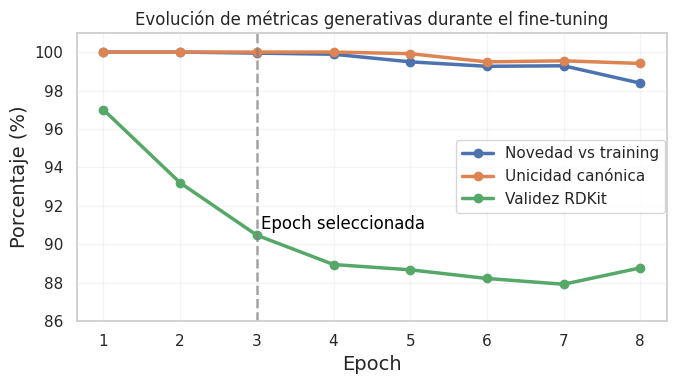

In [82]:
MRL_HISTORY_PATH = MRL_DIR / "finetuning_monitoring_history.csv"
df_epochs = pd.read_csv(MRL_HISTORY_PATH)

metric_cols = [
    "percent_valid",
    "percent_unique_raw",
    "percent_unique_valid",
    "percent_novel_vs_training",
]

for col in metric_cols:
    df_epochs[col + "_pct"] = df_epochs[col] * 100

plot_metrics = [
    "percent_valid_pct",
    "percent_unique_valid_pct",
    "percent_novel_vs_training_pct",
]

df_metrics_long = df_epochs.melt(
    id_vars="epoch",
    value_vars=plot_metrics,
    var_name="metric",
    value_name="value_pct",
)

metric_labels = {
    "percent_valid_pct": "Validez RDKit",
    "percent_unique_valid_pct": "Unicidad canónica",
    "percent_novel_vs_training_pct": "Novedad vs training",
}
df_metrics_long["metric"] = df_metrics_long["metric"].map(metric_labels)

fig, ax = plt.subplots(figsize=(7, 4))
for metric, sub in df_metrics_long.groupby("metric"):
    ax.plot(sub["epoch"], sub["value_pct"], marker="o", linewidth=2.5, label=metric)

ax.axvline(x=3, linestyle="--", linewidth=1.8, alpha=0.7, color="gray")
ax.text(3.05, 90.6, "Epoch seleccionada", fontsize=12, va="bottom", color="black")
ax.set_title("Evolución de métricas generativas durante el fine-tuning")
ax.set_xlabel("Epoch", fontsize=14)
ax.set_ylabel("Porcentaje (%)", fontsize=14)
ax.set_xticks(df_epochs["epoch"])
ax.set_ylim(86, 101)
ax.grid(alpha=0.2)
ax.legend(title=None, loc="lower center", bbox_to_anchor=(0.82, 0.35))

plt.tight_layout()
save_current_figure("fig_02_metricas_generativas_epoch.png")
plt.show()


## 5. Filtrado fisicoquímico

Esta sección analiza las moléculas que superaron el filtro básico antes del scoring final. Es importante porque demuestra que la pipeline no solo generó SMILES válidos, sino moléculas con rangos fisicoquímicos razonables para una exploración inicial de pequeñas moléculas *drug-like*.


Figura guardada: /home/kluna/TFM-EGFR-ETL/TFM/resultados_figuras/fig_05_distribuciones_fisicoquimicas_filtrado.png


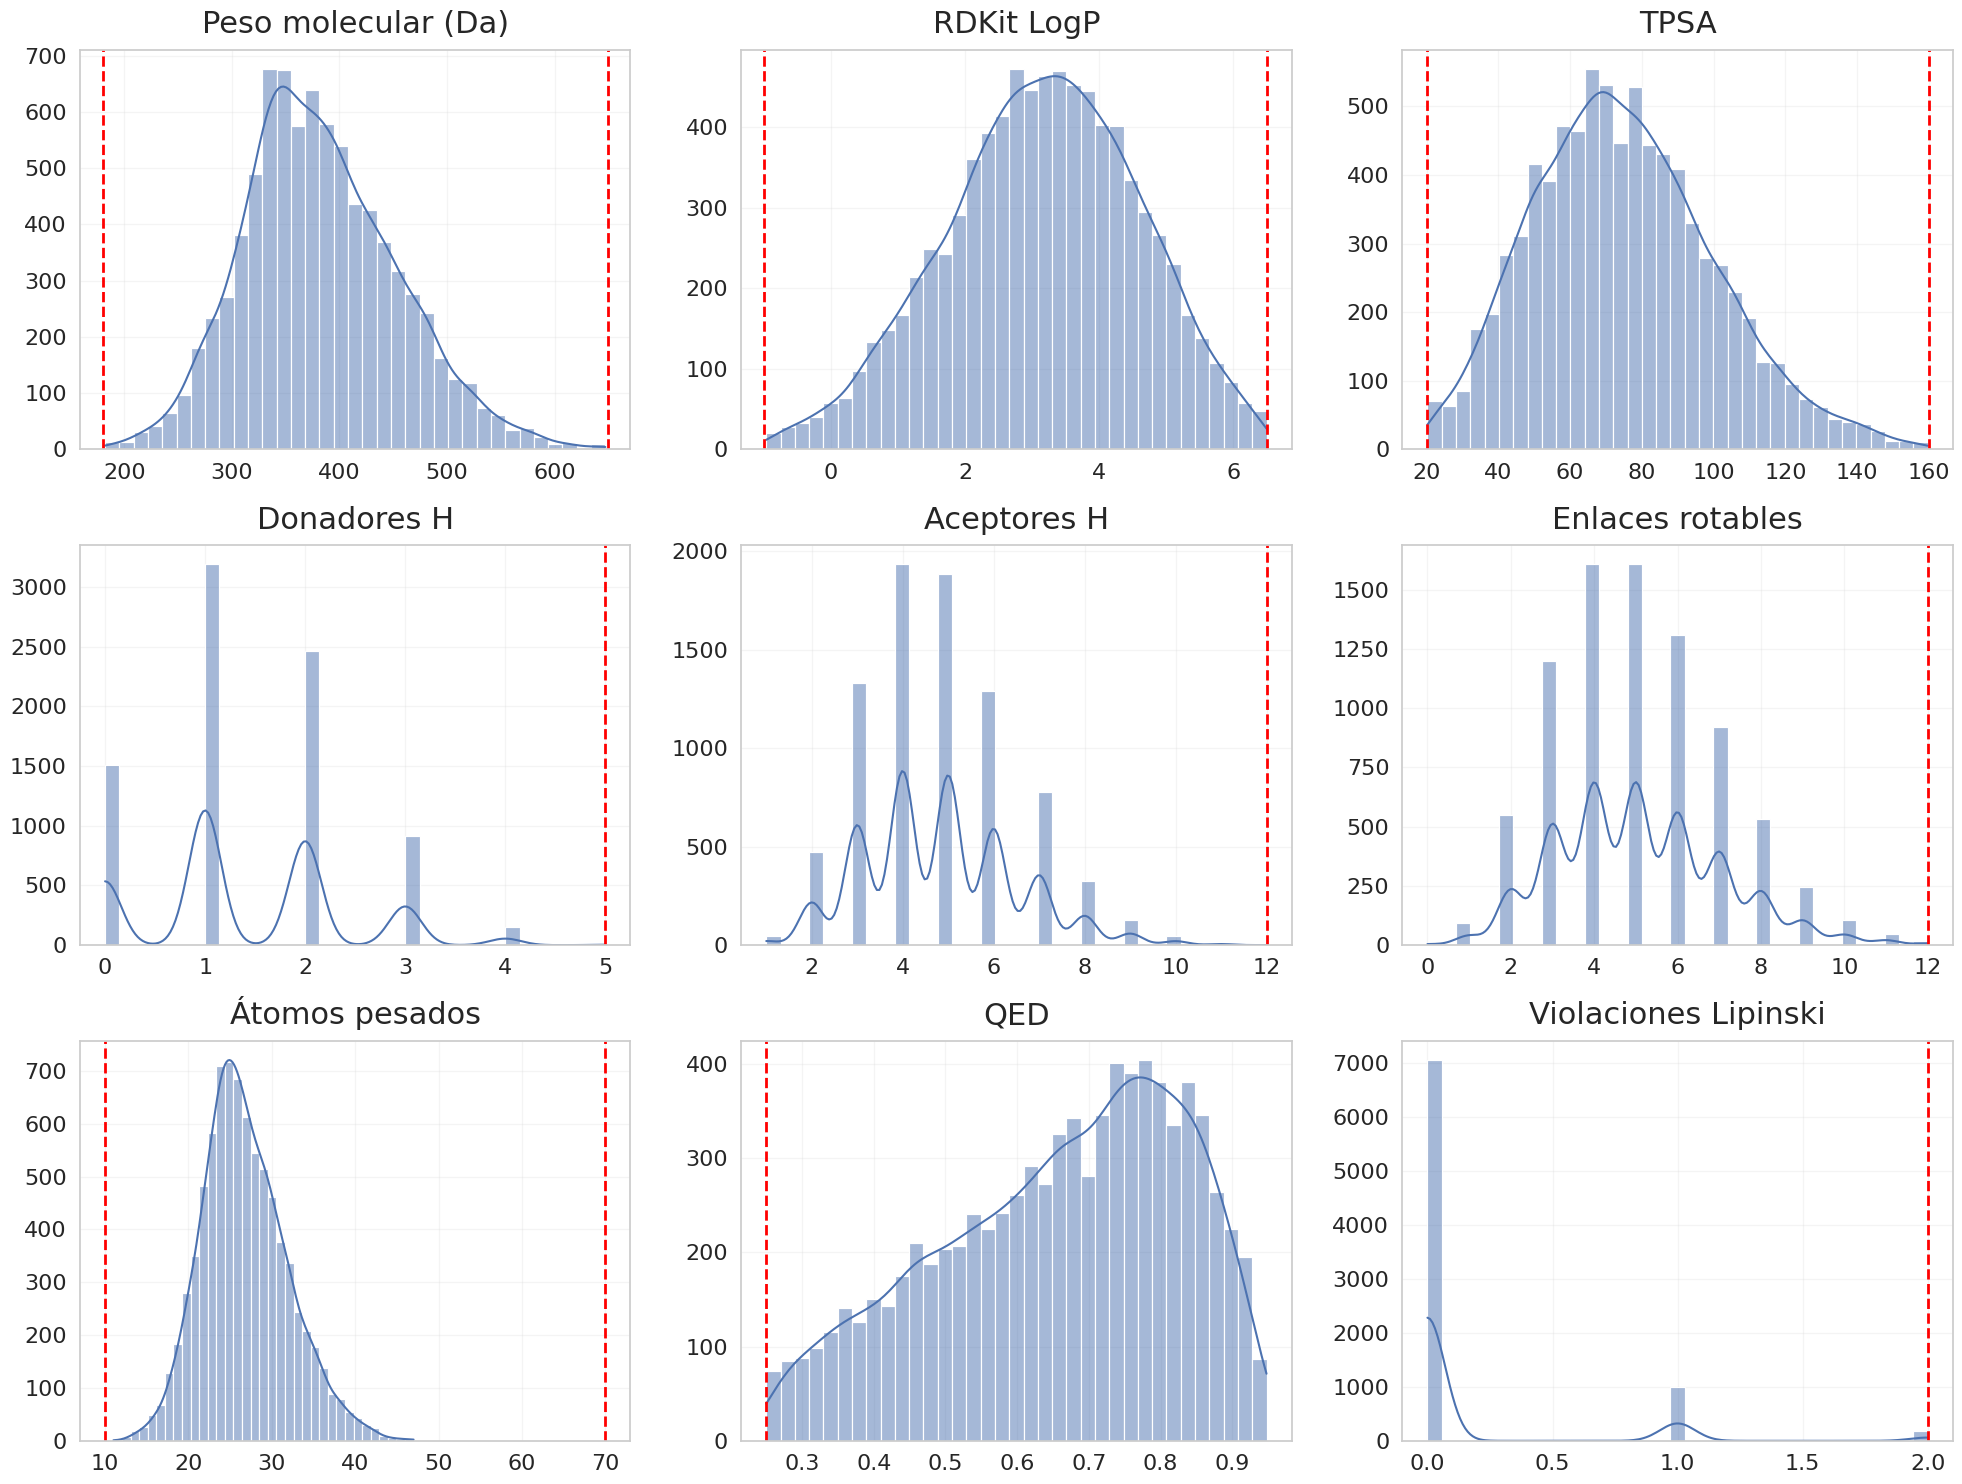

,mean,std,min,25%,50%,75%,max
mol_wt,382.509,72.143,182.179,333.313,375.448,428.867,647.180
rdkit_logp,3.150,1.446,-0.965,2.185,3.202,4.187,6.497
tpsa,74.935,25.294,20.200,56.790,72.950,91.140,159.700
hbd,1.398,0.977,0.000,1.000,1.000,2.000,5.000
hba,4.810,1.666,1.000,4.000,5.000,6.000,12.000
rot_bonds,5.070,1.970,0.000,4.000,5.000,6.000,12.000
heavy_atoms,26.797,5.120,11.000,23.000,26.000,30.000,47.000
qed,0.658,0.171,0.250,0.534,0.684,0.797,0.948
ro5_violations,0.166,0.428,0.000,0.000,0.000,0.000,2.000


In [81]:
FILTERED_PATH = SCORING_INTERMEDIATE_DIR / "02_generated_molecules_filtered.csv"
DESCRIPTORS_PATH = SCORING_INTERMEDIATE_DIR / "01_generated_molecules_descriptors.csv"

df_filtered = pd.read_csv(FILTERED_PATH)
df_generated = pd.read_csv(DESCRIPTORS_PATH)

descriptor_specs = [
    ("mol_wt", "Peso molecular (Da)", 180, 650),
    ("rdkit_logp", "RDKit LogP", -1, 6.5),
    ("tpsa", "TPSA", 20, 160),
    ("hbd", "Donadores H", None, 5),
    ("hba", "Aceptores H", None, 12),
    ("rot_bonds", "Enlaces rotables", None, 12),
    ("heavy_atoms", "Átomos pesados", 10, 70),
    ("qed", "QED", 0.25, None),
    ("ro5_violations", "Violaciones Lipinski", None, 2),
]

n_cols = 3
n_rows = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 15))
axes = axes.flatten()


for ax, (col, label, min_thr, max_thr) in zip(axes, descriptor_specs):
    sns.histplot(
        data=df_filtered,
        x=col,
        bins=35,
        kde=True,
        ax=ax
    )

    if min_thr is not None:
        ax.axvline(min_thr, linestyle="--", linewidth=2, color="red")

    if max_thr is not None:
        ax.axvline(max_thr, linestyle="--", linewidth=2, color="red")

    ax.set_title(label, fontsize=22, pad=12)
    ax.set_xlabel(None)
    ax.set_ylabel(None)

    ax.tick_params(axis="x", labelsize=16)
    ax.tick_params(axis="y", labelsize=16)


for ax in axes:
    ax.grid(alpha=0.2)


plt.tight_layout()
save_current_figure("fig_05_distribuciones_fisicoquimicas_filtrado.png")
plt.show()

descriptor_cols = [spec[0] for spec in descriptor_specs]
descriptor_summary = (
    df_filtered[descriptor_cols]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
    .round(3)
)
descriptor_summary.to_csv(OUTPUT_DIR / "tabla_resumen_descriptores_filtrados.csv")
display(descriptor_summary)


## 6. Selección multiobjetivo mediante Pareto

La selección por Pareto es el núcleo metodológico del trabajo: evita reducir el problema a una única suma ponderada y permite conservar moléculas que representan compromisos distintos entre actividad, ADMET, similitud, QED y Lipinski.

La visualización por coordenadas paralelas se usa porque hay más de dos objetivos y un gráfico 2D ocultaría parte del problema.


Figura guardada: /home/kluna/TFM-EGFR-ETL/TFM/resultados_figuras/fig_pareto_parallel_eligible_vs_pareto.png


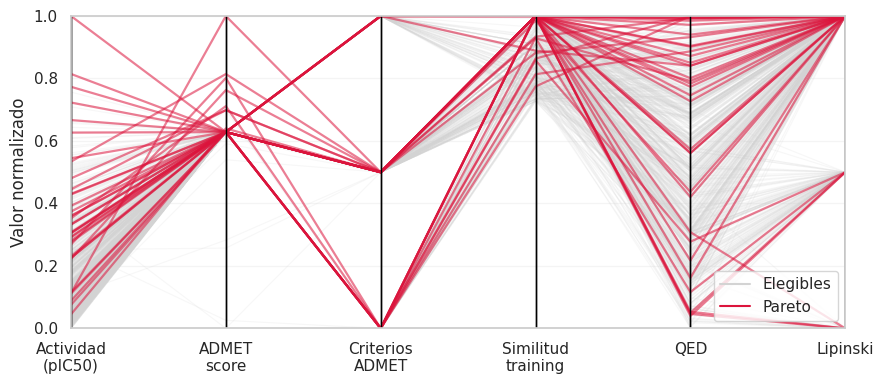

In [89]:
objective_cols = [
    "predicted_pIC50",
    "score_admet",
    "score_admet_hard",
    "score_training_similarity",
    "score_qed",
    "score_ro5",
]

pareto_smiles = set(pareto["smiles"])
eligible_pc = eligible.copy()
pareto_pc = pareto.copy()
eligible_pc["is_pareto"] = eligible_pc["smiles"].isin(pareto_smiles)

for col in objective_cols:
    col_min = eligible_pc[col].min()
    col_max = eligible_pc[col].max()

    if col_max > col_min:
        eligible_pc[col + "_norm"] = (eligible_pc[col] - col_min) / (col_max - col_min)
        pareto_pc[col + "_norm"] = (pareto_pc[col] - col_min) / (col_max - col_min)
    else:
        eligible_pc[col + "_norm"] = 0.0
        pareto_pc[col + "_norm"] = 0.0

norm_cols = [c + "_norm" for c in objective_cols]
pretty_labels = {
    "predicted_pIC50_norm": "Actividad\n(pIC50)",
    "score_admet_norm": "ADMET\nscore",
    "score_admet_hard_norm": "Criterios\nADMET",
    "score_training_similarity_norm": "Similitud\ntraining",
    "score_qed_norm": "QED",
    "score_ro5_norm": "Lipinski",
}

df_bg = eligible_pc[~eligible_pc["is_pareto"]].copy()
if len(df_bg) > 600:
    df_bg = df_bg.sample(600, random_state=SEED)

df_bg_plot = df_bg[norm_cols].copy()
df_bg_plot["grupo"] = "Elegibles"

df_pareto_plot = pareto_pc[norm_cols].copy()
df_pareto_plot["grupo"] = "Pareto"

df_parallel_all = pd.concat([df_bg_plot, df_pareto_plot], ignore_index=True)
df_parallel_all = df_parallel_all.rename(columns=pretty_labels)

plt.figure(figsize=(9,4))
parallel_coordinates(
    df_parallel_all[df_parallel_all["grupo"] == "Elegibles"],
    class_column="grupo",
    color=["lightgray"],
    alpha=0.18,
    linewidth=0.8,
)
parallel_coordinates(
    df_parallel_all[df_parallel_all["grupo"] == "Pareto"],
    class_column="grupo",
    color=["crimson"],
    alpha=0.55,
    linewidth=1.6,
)

plt.title(None)
plt.xlabel(None)
plt.ylabel("Valor normalizado")
plt.ylim(0, 1)
plt.grid(alpha=0.2)

import matplotlib.lines as mlines
gray_line = mlines.Line2D([], [], color="lightgray", label="Elegibles")
red_line = mlines.Line2D([], [], color="crimson", label="Pareto")
plt.legend(handles=[gray_line, red_line], loc="lower right")

plt.tight_layout()
save_current_figure("fig_pareto_parallel_eligible_vs_pareto.png")
plt.show()


## 7. Distribución global de la shortlist final

Una vez obtenidas las 30 candidatas, esta figura resume las variables que más ayudan a interpretar la shortlist: actividad, score global, QED, ADMET y similitud frente al entrenamiento y frente a inhibidores EGFR conocidos.

Esta visualización debe aparecer antes de entrar en perfiles individuales.


Figura guardada: /home/kluna/TFM-EGFR-ETL/TFM/resultados_figuras/fig_02_distribuciones_shortlist.png


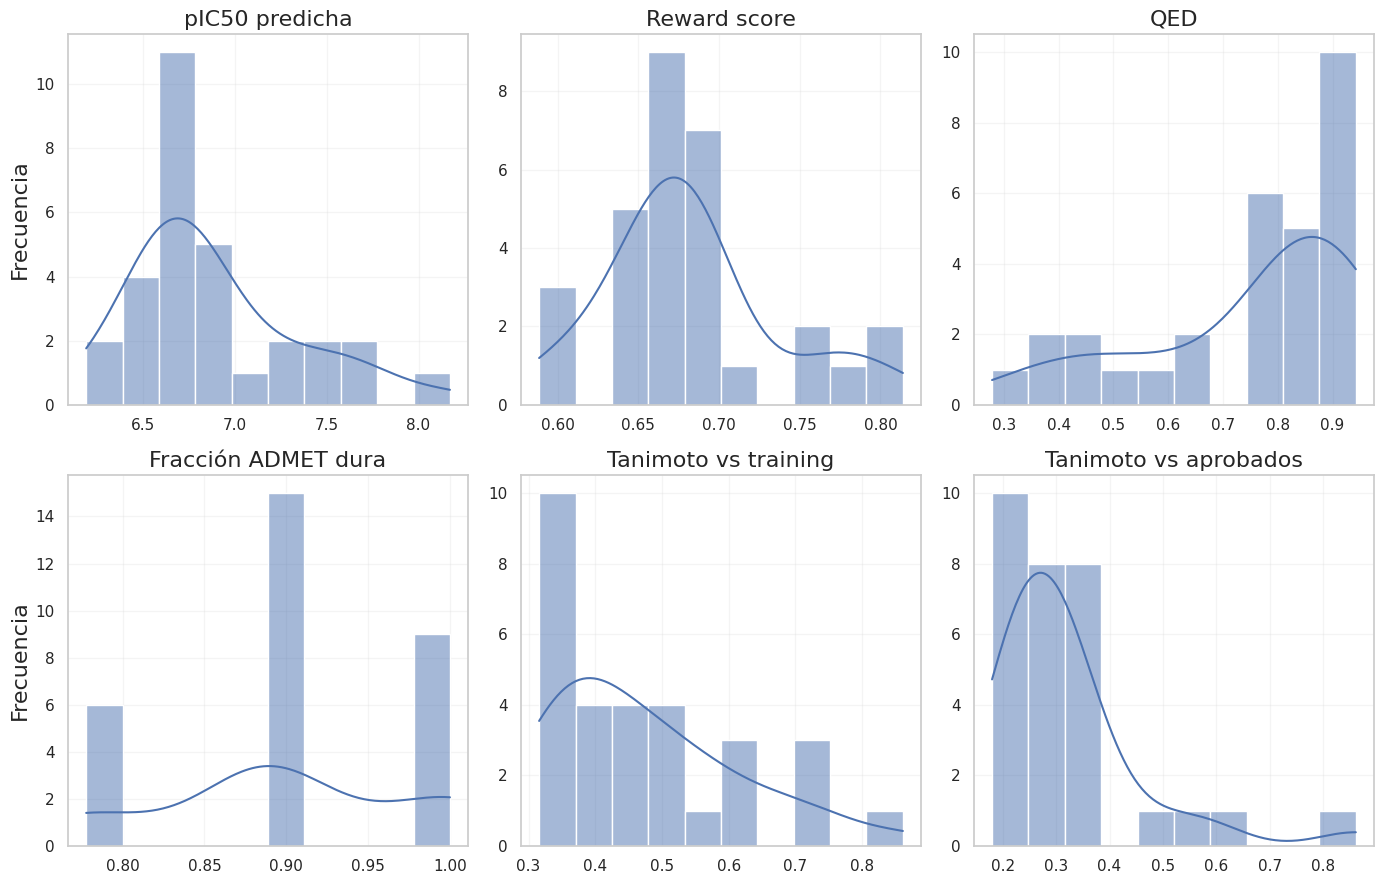

In [85]:
vars_dist = [
    ("predicted_pIC50", "pIC50 predicha"),
    ("reward_score", "Reward score"),
    ("qed", "QED"),
    ("admet_hard_pass_fraction", "Fracción ADMET dura"),
    ("max_tanimoto_training", "Tanimoto vs training"),
    ("max_tanimoto_approved_egfr", "Tanimoto vs aprobados"),
]

fig, axes = plt.subplots(2,3, figsize=(14,9))
for ax, (col,label) in zip(axes.flat, vars_dist):
    sns.histplot(shortlist, x=col, kde=True, bins=10, ax=ax, color="#4C72B0")
    ax.set_title(label, fontsize=16)
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    ax.grid(alpha=0.2)
    if ax in [axes[0,0], axes[1,0]]:
        ax.set_ylabel("Frecuencia", fontsize=16)

plt.tight_layout()
save_current_figure("fig_02_distribuciones_shortlist.png")
plt.show()


## 8. Actividad, calidad molecular y ADMET

Aquí se interpreta la shortlist desde una perspectiva farmacológica temprana. El punto clave para la memoria es no caer en una conclusión ingenua: una molécula con alta `predicted_pIC50` puede ser menos defendible si falla criterios ADMET críticos, especialmente hERG.


Figura guardada: /home/kluna/TFM-EGFR-ETL/TFM/resultados_figuras/fig_shortlist_pIC50_vs_admet.png


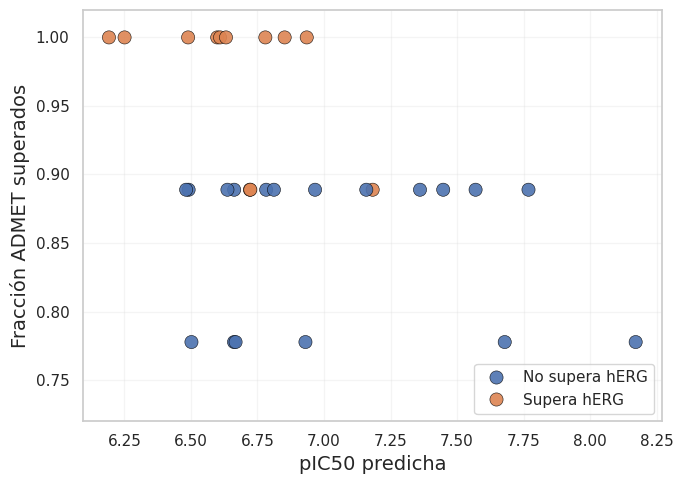

In [86]:
ADMET_FRACTION_COL = "admet_hard_pass_fraction"

plot_df = df.copy()
hue_col = "pass_hERG"
df["hERG_label"] = df["pass_hERG"].map({
        True: "Supera hERG",
        False: "No supera hERG"
    })



plt.figure(figsize=(7, 5))


ax = sns.scatterplot(
        data=df,
        x="predicted_pIC50",
        y=ADMET_FRACTION_COL,
        hue="hERG_label",
        s=90,
        edgecolor="black",
        linewidth=0.4,
        alpha=0.9
    )

# Etiquetar candidatas 
#for _, row in df.iterrows():
#   ax.text(
 #       row["predicted_pIC50"] + 0.015,
  #      row[ADMET_FRACTION_COL] + 0.009,
   #     row["candidate_id"],
    #    fontsize=8,
     #   alpha=0.75)

ax.set_title(None)
ax.set_xlabel("pIC50 predicha", fontsize=14)
ax.set_ylabel("Fracción ADMET superados", fontsize=14)
ax.set_ylim(0.72, 1.02)
ax.legend(loc="lower right")
ax.grid(alpha=0.2)

plt.tight_layout()
save_current_figure("fig_shortlist_pIC50_vs_admet.png")
plt.show()


Figura guardada: /home/kluna/TFM-EGFR-ETL/TFM/resultados_figuras/fig_shortlist_admet_heatmap.png


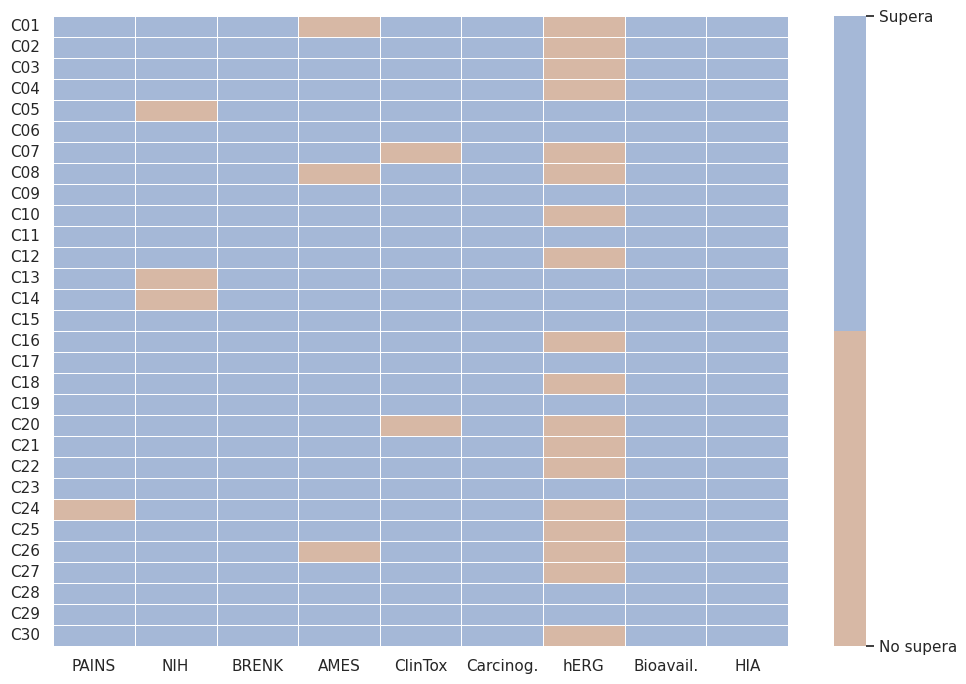

In [60]:
admet_pass_cols = [
    "pass_PAINS_alert",
    "pass_NIH_alert",
    "pass_BRENK_alert",
    "pass_AMES",
    "pass_ClinTox",
    "pass_Carcinogens_Lagunin",
    "pass_hERG",
    "pass_Bioavailability_Ma",
    "pass_HIA_Hou",
]

admet_labels = {
    "pass_PAINS_alert": "PAINS",
    "pass_NIH_alert": "NIH",
    "pass_BRENK_alert": "BRENK",
    "pass_AMES": "AMES",
    "pass_ClinTox": "ClinTox",
    "pass_Carcinogens_Lagunin": "Carcinog.",
    "pass_hERG": "hERG",
    "pass_Bioavailability_Ma": "Bioavail.",
    "pass_HIA_Hou": "HIA",
}

heatmap_data = df.set_index("candidate_id")[admet_pass_cols].copy()
heatmap_data = heatmap_data.rename(columns=admet_labels)

plt.figure(figsize=(10, 7))

ax = sns.heatmap(
    heatmap_data,
    cmap=sns.color_palette(["#D7B8A5", "#A5B8D7"], as_cmap=True),
    cbar_kws={"ticks": [0, 1], "label": None},
    linewidths=0.5,
    linecolor="white"
)

# Ajustar etiquetas de la barra de color
cbar = ax.collections[0].colorbar
cbar.set_ticklabels(["No supera", "Supera"])

ax.set_title(None)
ax.set_xlabel(None)
ax.set_ylabel(None)

plt.tight_layout()
save_current_figure("fig_shortlist_admet_heatmap.png")
plt.show()


Figura guardada: /home/kluna/TFM-EGFR-ETL/TFM/resultados_figuras/fig_actividad_vs_qed_reward.png


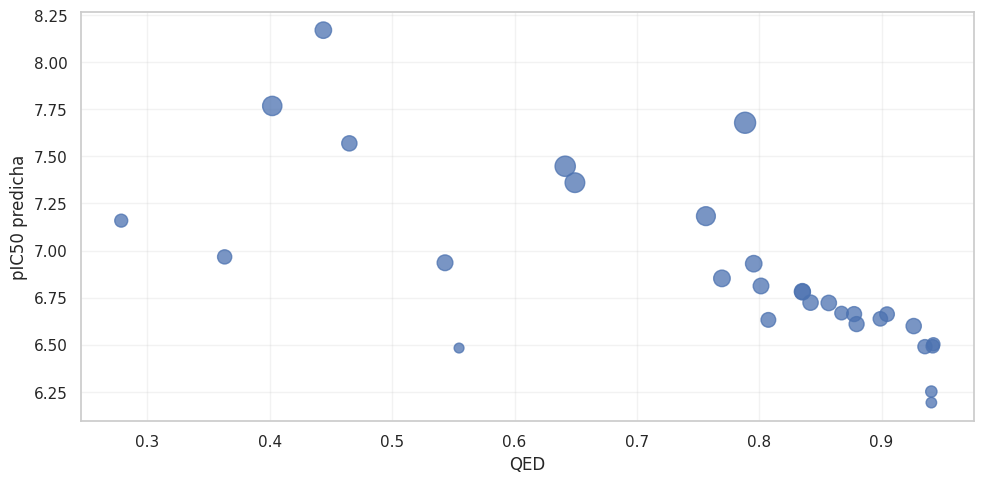

In [91]:
# Actividad frente a QED, con tamaño proporcional al reward_score.
sizes = 50 + 180 * minmax_score(df["reward_score"], True)
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df["qed"], df["predicted_pIC50"], s=sizes, alpha=0.75)
ax.set_xlabel("QED")
ax.set_ylabel("pIC50 predicha")
ax.set_title(None)
ax.grid(True, alpha=0.25)
plt.tight_layout()
save_current_figure("fig_actividad_vs_qed_reward.png")
plt.show()


In [35]:
endpoint_summary = (
    heatmap_data
    .sum()
    .rename("n_pass")
    .reset_index()
    .rename(columns={"index": "endpoint_label"})
)
endpoint_summary["n_fail"] = len(df) - endpoint_summary["n_pass"]
endpoint_summary["pct_pass"] = 100 * endpoint_summary["n_pass"] / len(df)
endpoint_summary = endpoint_summary.sort_values("n_pass", ascending=True)


display(endpoint_summary)

summary_table_cols = [
    "predicted_pIC50",
    "reward_score",
    "qed",
    "ro5_violations",
    ADMET_FRACTION_COL,
]
summary_table = (
    df[summary_table_cols]
    .describe()
    .T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
    .round(3)
)
summary_table.to_csv(OUTPUT_DIR / "tabla_resumen_shortlist_actividad_admet.csv")
display(summary_table)

print("Candidatas que superan hERG:", int(plot_df["pass_hERG"].sum()), "/", len(df))
print("Candidatas que no superan hERG:", int((~plot_df["pass_hERG"]).sum()), "/", len(df))


,endpoint_label,n_pass,n_fail,pct_pass
6,hERG,12,18,40.000000
1,NIH,27,3,90.000000
3,AMES,27,3,90.000000
4,ClinTox,28,2,93.333333
0,PAINS,29,1,96.666667
2,BRENK,30,0,100.000000
5,Carcinog.,30,0,100.000000
7,Bioavail.,30,0,100.000000
8,HIA,30,0,100.000000


,mean,std,min,25%,50%,75%,max
predicted_pIC50,6.891,0.465,6.192,6.615,6.751,7.111,8.171
reward_score,0.682,0.054,0.588,0.656,0.677,0.698,0.814
qed,0.749,0.197,0.279,0.643,0.821,0.894,0.942
ro5_violations,0.133,0.434,0.000,0.000,0.000,0.000,2.000
admet_hard_pass_fraction,0.900,0.079,0.778,0.889,0.889,1.000,1.000


Candidatas que superan hERG: 12 / 30
Candidatas que no superan hERG: 18 / 30


## 9. Novedad estructural y similitud frente a inhibidores EGFR conocidos

Esta sección separa dos ideas que a veces se mezclan mal: novedad frente al conjunto de entrenamiento y similitud frente a inhibidores EGFR aprobados o de referencia.

Una molécula muy novedosa puede ser interesante, pero también más incierta. Una molécula muy cercana a un aprobado puede ser plausible, pero menos original.


Figura guardada: /home/kluna/TFM-EGFR-ETL/TFM/resultados_figuras/fig_shortlist_tanimoto_training_vs_approved.png


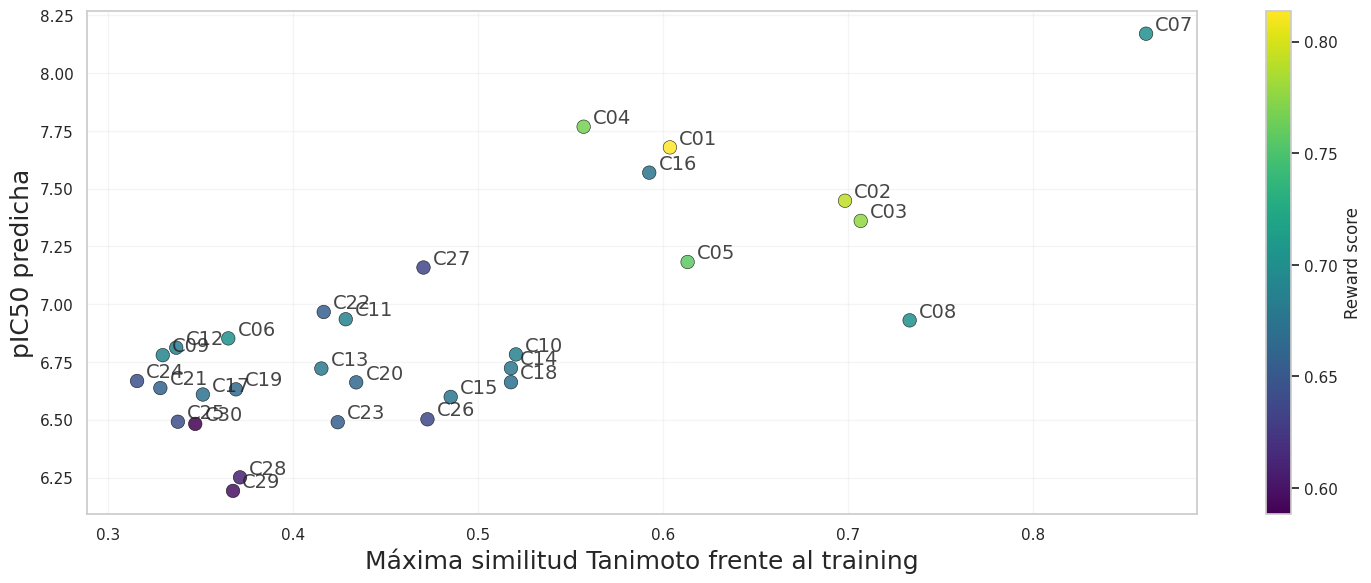

In [95]:
# Actividad predicha frente a novedad estructural, coloreada por reward_score
fig, ax = plt.subplots(figsize=(15, 6))

norm = plt.Normalize(df["reward_score"].min(), df["reward_score"].max())
cmap = plt.cm.viridis

sns.scatterplot(
    data=df,
    x="max_tanimoto_training",
    y="predicted_pIC50",
    hue="reward_score",
    palette=cmap,
    hue_norm=norm,
    s=95,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.4,
    legend=False,
    ax=ax,
)

# Etiquetas con candidate_id
for _, row in df.iterrows():
    ax.text(
        row["max_tanimoto_training"] + 0.005,
        row["predicted_pIC50"] + 0.015,
        row["candidate_id"],
        fontsize=14,
        alpha=0.85,
    )

ax.set_xlabel("Máxima similitud Tanimoto frente al training", fontsize=18)
ax.set_ylabel("pIC50 predicha", fontsize=18)
ax.set_title(None)
ax.grid(alpha=0.2)

# Barra de color
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Reward score")

plt.tight_layout()
save_current_figure("fig_shortlist_tanimoto_training_vs_approved.png")
plt.show()

In [37]:
# Comparación visual de C07 con su inhibidor EGFR aprobado/de referencia más cercano.
REFERENCE_CSV_PATH = PROJECT_ROOT / "data" / "fda_ema_egfr_reference.csv"

candidate_id_for_comparison = "C07"
row = df.loc[df["candidate_id"] == candidate_id_for_comparison].iloc[0]
df_ref = pd.read_csv(REFERENCE_CSV_PATH)


nearest_approved_name = row.nearest_approved_egfr_name
ref_match = df_ref[df_ref["drug_name"] == nearest_approved_name]

Figura guardada: /home/kluna/TFM-EGFR-ETL/TFM/resultados_figuras/fig_c07_comparacion_tanimoto.png


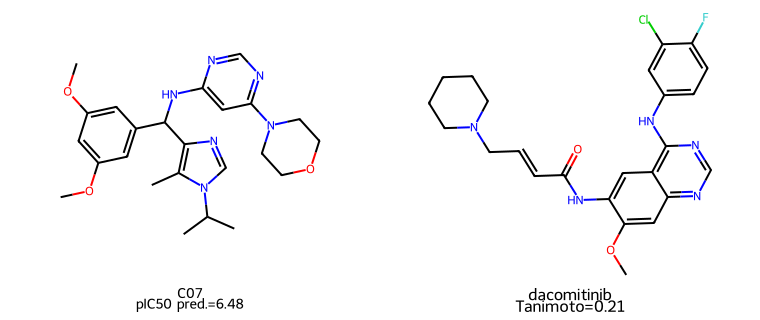

Aprobado/referencia más cercano: dacomitinib


In [75]:
mol_candidate = Chem.MolFromSmiles(row.smiles)
mol_approved = Chem.MolFromSmiles(ref_match.iloc[0]["smiles"])

for mol in [mol_candidate, mol_approved]:
    rdDepictor.Compute2DCoords(mol)

legends = [
    f"{candidate_id_for_comparison}\npIC50 pred.={row['predicted_pIC50']:.2f}",
    f"{nearest_approved_name}\nTanimoto={row['max_tanimoto_approved_egfr']:.2f}",
]

draw_options = rdMolDraw2D.MolDrawOptions()
draw_options.legendFontSize = 26

img = Draw.MolsToGridImage(
    [mol_candidate, mol_approved],
    molsPerRow=2,
    subImgSize=(380, 320),
    legends=legends,
    useSVG=False,
    returnPNG=False,
    drawOptions=draw_options,
)

output_path = OUTPUT_DIR / "fig_c07_comparacion_tanimoto.png"
save_rdkit_image(img, output_path)
display(img)

print("Aprobado/referencia más cercano:", nearest_approved_name)


## 10. Rankings interpretativos



In [39]:
summary_cols = [
    "candidate_id",
    "smiles",
    "predicted_pIC50",
    "reward_score",
    "admet_score",
    "admet_hard_pass_fraction",
    "qed",
    "ro5_violations",
    "max_tanimoto_training",
    "max_tanimoto_approved_egfr",
    "nearest_approved_egfr_name",
    "murcko_scaffold",
    "pass_hERG",
]

top_by_reward = df.sort_values("reward_score", ascending=False).head(5)
display(Markdown("### Top 5 por `reward_score`"))
display(top_by_reward[summary_cols])

top_by_activity = df.sort_values("predicted_pIC50", ascending=False).head(5)
display(Markdown("### Top 5 por actividad predicha"))
display(top_by_activity[summary_cols])

admet_sort_cols = ["admet_hard_pass_fraction", "admet_score", "reward_score"]
top_by_admet = df.sort_values(admet_sort_cols, ascending=[False, False, False]).head(5)
display(Markdown("### Top 5 por perfil ADMET"))
display(top_by_admet[summary_cols])

top_by_novelty = (
    df[df["predicted_pIC50"] >= 6.0]
    .sort_values(["max_tanimoto_training", "reward_score"], ascending=[True, False])
    .head(5)
)
display(Markdown("### Top 5 más novedosas frente al entrenamiento, manteniendo actividad predicha"))
display(top_by_novelty[summary_cols])


### Top 5 por `reward_score`

,candidate_id,smiles,predicted_pIC50,reward_score,admet_score,admet_hard_pass_fraction,qed,ro5_violations,max_tanimoto_training,max_tanimoto_approved_egfr,nearest_approved_egfr_name,murcko_scaffold,pass_hERG
0,C01,COc1ccc2ncnc(Nc3cccc(Cl)c3F)c2c1,7.678820,0.813901,0.339286,0.777778,0.788442,0,0.603774,0.355263,gefitinib,c1ccc(Nc2ncnc3ccccc23)cc1,False
1,C02,O=C(Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1)C1CCOCC1,7.447770,0.792513,0.339286,0.888889,0.641418,0,0.698413,0.354839,afatinib,O=C(Nc1ccc2ncnc(Nc3ccccc3)c2c1)C1CCOCC1,False
2,C03,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OC1CC2(COC2)C1,7.360564,0.776262,0.339286,0.888889,0.649353,0,0.706897,0.594595,gefitinib,c1ccc(Nc2ncnc3ccc(OC4CC5(COC5)C4)cc23)cc1,False
3,C04,O=C(Nc1cc2c(Nc3cccc(Br)c3)ncnc2cn1)Nc1nc2n(n1)CCCC2,7.768092,0.767045,0.339286,0.888889,0.401990,0,0.557143,0.290000,dacomitinib,O=C(Nc1cc2c(Nc3ccccc3)ncnc2cn1)Nc1nc2n(n1)CCCC2,False
4,C05,C=CC(=O)Nc1cc(Nc2ncc(C)cn2)c(OC)cc1N1CCOCC1,7.182763,0.756761,0.339286,0.888889,0.756415,0,0.613333,0.534884,lazertinib,c1cnc(Nc2ccc(N3CCOCC3)cc2)nc1,True


### Top 5 por actividad predicha

,candidate_id,smiles,predicted_pIC50,reward_score,admet_score,admet_hard_pass_fraction,qed,ro5_violations,max_tanimoto_training,max_tanimoto_approved_egfr,nearest_approved_egfr_name,murcko_scaffold,pass_hERG
6,C07,CCOc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CN1CCCC1,8.170641,0.701087,0.339286,0.777778,0.443757,1,0.861111,0.861111,dacomitinib,O=C(/C=C/CN1CCCC1)Nc1ccc2ncnc(Nc3ccccc3)c2c1,False
3,C04,O=C(Nc1cc2c(Nc3cccc(Br)c3)ncnc2cn1)Nc1nc2n(n1)CCCC2,7.768092,0.767045,0.339286,0.888889,0.401990,0,0.557143,0.290000,dacomitinib,O=C(Nc1cc2c(Nc3ccccc3)ncnc2cn1)Nc1nc2n(n1)CCCC2,False
0,C01,COc1ccc2ncnc(Nc3cccc(Cl)c3F)c2c1,7.678820,0.813901,0.339286,0.777778,0.788442,0,0.603774,0.355263,gefitinib,c1ccc(Nc2ncnc3ccccc23)cc1,False
15,C16,COc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OC1CN(C(=O)OC(C)(C)C)CC1F,7.569358,0.676497,0.339286,0.888889,0.465007,2,0.592593,0.357143,erlotinib,c1ccc(Nc2ncnc3ccc(OC4CCNC4)cc23)cc1,False
1,C02,O=C(Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1)C1CCOCC1,7.447770,0.792513,0.339286,0.888889,0.641418,0,0.698413,0.354839,afatinib,O=C(Nc1ccc2ncnc(Nc3ccccc3)c2c1)C1CCOCC1,False


### Top 5 por perfil ADMET

,candidate_id,smiles,predicted_pIC50,reward_score,admet_score,admet_hard_pass_fraction,qed,ro5_violations,max_tanimoto_training,max_tanimoto_approved_egfr,nearest_approved_egfr_name,murcko_scaffold,pass_hERG
5,C06,CC(C)n1cnc2ncnc(Nc3cccc(CO)c3)c21,6.852217,0.703727,0.339286,1.0,0.769510,0,0.365079,0.281690,erlotinib,c1ccc(Nc2ncnc3nc[nH]c23)cc1,True
8,C09,CC(=O)NC1CCN(C(=O)C23CC(CN2c2ncnc4cc(Cl)ccc24)C3)CC1,6.779645,0.690375,0.339286,1.0,0.835345,0,0.329670,0.240000,dacomitinib,O=C(N1CCCCC1)C12CC(CN1c1ncnc3ccccc13)C2,True
10,C11,COc1ccc2c(NC(CO)C(O)c3ccc(S(C)(=O)=O)cc3)ncnc2c1,6.935125,0.686361,0.339286,1.0,0.543195,0,0.428571,0.237500,erlotinib,c1ccc(CCNc2ncnc3ccccc23)cc1,True
14,C15,CCc1ncnc(Nc2ccc(F)c(C#N)c2)c1OC,6.598890,0.676569,0.339286,1.0,0.926227,0,0.485294,0.316456,gefitinib,c1ccc(Nc2ccncn2)cc1,True
16,C17,NC(=O)c1cc(Nc2cncc(N3CCOCC3)c2)ccn1,6.609368,0.671664,0.339286,1.0,0.879554,0,0.351351,0.230000,lazertinib,c1cc(Nc2cncc(N3CCOCC3)c2)ccn1,True


### Top 5 más novedosas frente al entrenamiento, manteniendo actividad predicha

,candidate_id,smiles,predicted_pIC50,reward_score,admet_score,admet_hard_pass_fraction,qed,ro5_violations,max_tanimoto_training,max_tanimoto_approved_egfr,nearest_approved_egfr_name,murcko_scaffold,pass_hERG
23,C24,Cc1cc(N2CCSCC2)ccc1NC(=O)/C=C/c1ccncn1,6.667808,0.644627,0.339286,0.777778,0.867281,0,0.315789,0.231579,dacomitinib,O=C(/C=C/c1ccncn1)Nc1ccc(N2CCSCC2)cc1,False
20,C21,Cc1nc(N(C)CC(C)NC(=O)C2CCN(C)C2)c2ccccc2n1,6.637261,0.659769,0.339286,0.888889,0.898969,0,0.328358,0.227723,osimertinib,O=C(NCCNc1ncnc2ccccc12)C1CCNC1,False
8,C09,CC(=O)NC1CCN(C(=O)C23CC(CN2c2ncnc4cc(Cl)ccc24)C3)CC1,6.779645,0.690375,0.339286,1.000000,0.835345,0,0.329670,0.240000,dacomitinib,O=C(N1CCCCC1)C12CC(CN1c1ncnc3ccccc13)C2,True
11,C12,CC1OCCN(C(=O)c2nccnc2Nc2ccc(N3CCN(C)CC3)cc2F)C1C,6.811856,0.683741,0.339286,0.888889,0.801426,0,0.336957,0.201923,dacomitinib,O=C(c1nccnc1Nc1ccc(N2CCNCC2)cc1)N1CCOCC1,False
24,C25,Nc1ncc(CN2CCN(c3ccc(F)c(Cl)c3)CC2)s1,6.491466,0.641094,0.339286,0.888889,0.941782,0,0.337838,0.256098,gefitinib,c1ccc(N2CCN(Cc3cncs3)CC2)cc1,False


## 11. Scaffolds de Murcko y diversidad química

El análisis por scaffold responde a una pregunta clave: ¿la shortlist final contiene alternativas químicas reales o solo variaciones de la misma familia?

Si hay muchos scaffolds distintos, la selección es más defendible como cartera exploratoria.


In [40]:
scaffold_summary = (
    df.groupby("murcko_scaffold")
    .agg(
        n_candidates=("smiles", "count"),
        mean_predicted_pIC50=("predicted_pIC50", "mean"),
        max_predicted_pIC50=("predicted_pIC50", "max"),
        mean_reward_score=("reward_score", "mean"),
        mean_qed=("qed", "mean"),
        mean_training_similarity=("max_tanimoto_training", "mean"),
        mean_admet_hard_pass_fraction=("admet_hard_pass_fraction", "mean"),
    )
    .reset_index()
    .sort_values(["n_candidates", "mean_reward_score"], ascending=[False, False])
)

n_unique_scaffolds = df["murcko_scaffold"].nunique()

print(f"Número de scaffolds únicos: {n_unique_scaffolds}")
print(f"Ratio scaffold/molécula: {n_unique_scaffolds / len(df):.2f}")

display(scaffold_summary.round(3))
scaffold_summary.to_csv(OUTPUT_DIR / "tabla_scaffolds_shortlist.csv", index=False)


Número de scaffolds únicos: 29
Ratio scaffold/molécula: 0.97


,murcko_scaffold,n_candidates,mean_predicted_pIC50,max_predicted_pIC50,mean_reward_score,mean_qed,mean_training_similarity,mean_admet_hard_pass_fraction
23,c1ccc(Nc2ncnc3ccccc23)cc1,2,7.305,7.679,0.757,0.792,0.669,0.778
7,O=C(Nc1ccc2ncnc(Nc3ccccc3)c2c1)C1CCOCC1,1,7.448,7.448,0.793,0.641,0.698,0.889
21,c1ccc(Nc2ncnc3ccc(OC4CC5(COC5)C4)cc23)cc1,1,7.361,7.361,0.776,0.649,0.707,0.889
5,O=C(Nc1cc2c(Nc3ccccc3)ncnc2cn1)Nc1nc2n(n1)CCCC2,1,7.768,7.768,0.767,0.402,0.557,0.889
28,c1cnc(Nc2ccc(N3CCOCC3)cc2)nc1,1,7.183,7.183,0.757,0.756,0.613,0.889
24,c1ccc(Nc2ncnc3nc[nH]c23)cc1,1,6.852,6.852,0.704,0.770,0.365,1.000
0,O=C(/C=C/CN1CCCC1)Nc1ccc2ncnc(Nc3ccccc3)c2c1,1,8.171,8.171,0.701,0.444,0.861,0.778
2,O=C(N1CCCCC1)C12CC(CN1c1ncnc3ccccc13)C2,1,6.780,6.780,0.690,0.835,0.330,1.000
4,O=C(Nc1cc(Nc2ccccc2)ncn1)C1CCNCC1,1,6.783,6.783,0.689,0.835,0.521,0.889
16,c1ccc(CCNc2ncnc3ccccc23)cc1,1,6.935,6.935,0.686,0.543,0.429,1.000


## 12. Estructuras 2D del top 4

La visualización 2D no valida una molécula, pero ayuda a detectar si el ranking está dominado por estructuras demasiado parecidas o por motivos químicos claramente problemáticos.

Esta figura debe complementar, no sustituir, las métricas.


Figura guardada: /home/kluna/TFM-EGFR-ETL/TFM/resultados_figuras/fig_top10_reward_moleculas.png


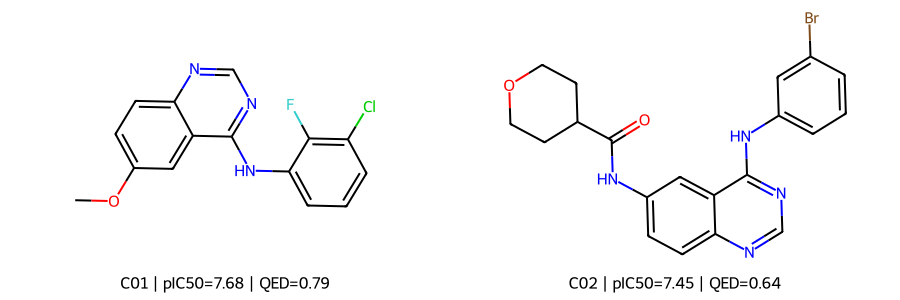

In [57]:
mols_top10 = []
legends_top10 = []

for _, row in top_by_reward.head(2).reset_index(drop=True).iterrows():
    mol = Chem.MolFromSmiles(row["smiles"])
    if mol is None:
        continue

    rdDepictor.Compute2DCoords(mol)
    mols_top10.append(mol)

    legend = (
        f"{row['candidate_id']} | pIC50={row['predicted_pIC50']:.2f} | QED={row['qed']:.2f}"
    )
    legends_top10.append(legend)

img_top10 = Draw.MolsToGridImage(
    mols_top10,
    molsPerRow=2,
    subImgSize=(450, 300),
    legends=legends_top10,
    useSVG=False,
    returnPNG=False,
)

save_rdkit_image(img_top10, OUTPUT_DIR / "fig_top10_reward_moleculas.png")
display(img_top10)


## 15. Perfiles interpretativos de candidatas

Este bloque traduce el análisis cuantitativo a perfiles defendibles para la memoria. La shortlist no debe leerse como un ranking lineal: una candidata puede ser interesante por equilibrio global, otra por actividad, otra por ADMET y otra por novedad estructural.

El criterio hERG se trata de forma independiente al resto de reglas ADMET. Esto permite separar dos lecturas: por un lado, fallos generales de absorción, alertas estructurales o toxicidad; por otro, una alerta específica de posible riesgo cardiotóxico computacional. Por eso se usa `risk_admet_failure` para ADMET general y `risk_hERG` para hERG.


In [42]:
profile_base = df.copy()

# Reglas ADMET generales. hERG se excluye deliberadamente para analizarlo como riesgo independiente.
admet_rule_cols_general = [
    "pass_PAINS_alert",
    "pass_NIH_alert",
    "pass_BRENK_alert",
    "pass_AMES",
    "pass_ClinTox",
    "pass_Carcinogens_Lagunin",
    "pass_Bioavailability_Ma",
    "pass_HIA_Hou",
]

profile_base["n_failed_admet_rules"] = (
    profile_base[admet_rule_cols_general] == False
).sum(axis=1)

profile_base["failed_admet_rules"] = profile_base[admet_rule_cols_general].apply(
    lambda row: row[row == False].index.tolist(),
    axis=1,
)

profile_base["risk_admet_failure"] = profile_base["n_failed_admet_rules"] > 0
profile_base["risk_hERG"] = profile_base["pass_hERG"] == False
profile_base["risk_near_training_copy"] = profile_base["max_tanimoto_training"] >= 0.85
profile_base["risk_low_qed"] = profile_base["qed"] < 0.35
profile_base["risk_ro5"] = profile_base["ro5_violations"] > 1

risk_flag_cols = [
    "risk_admet_failure",
    "risk_hERG",
    "risk_near_training_copy",
    "risk_low_qed",
    "risk_ro5",
]

profile_base["n_risk_flags"] = profile_base[risk_flag_cols].sum(axis=1)

display(
    profile_base[
        [
            "candidate_id",
            "predicted_pIC50",
            "reward_score",
            "admet_hard_pass_fraction",
            "qed",
            "ro5_violations",
            "max_tanimoto_training",
            "max_tanimoto_approved_egfr",
            "pass_hERG",
            "risk_admet_failure",
            "risk_hERG",
            "n_risk_flags",
        ]
    ]
    .sort_values("reward_score", ascending=False)
    .head(10)
    .round(3)
)

,candidate_id,predicted_pIC50,reward_score,admet_hard_pass_fraction,qed,ro5_violations,max_tanimoto_training,max_tanimoto_approved_egfr,pass_hERG,risk_admet_failure,risk_hERG,n_risk_flags
0,C01,7.679,0.814,0.778,0.788,0,0.604,0.355,False,True,True,2
1,C02,7.448,0.793,0.889,0.641,0,0.698,0.355,False,False,True,1
2,C03,7.361,0.776,0.889,0.649,0,0.707,0.595,False,False,True,1
3,C04,7.768,0.767,0.889,0.402,0,0.557,0.290,False,False,True,1
4,C05,7.183,0.757,0.889,0.756,0,0.613,0.535,True,True,False,1
5,C06,6.852,0.704,1.000,0.770,0,0.365,0.282,True,False,False,0
6,C07,8.171,0.701,0.778,0.444,1,0.861,0.861,False,True,True,3
7,C08,6.930,0.701,0.778,0.795,0,0.733,0.456,False,True,True,2
8,C09,6.780,0.690,1.000,0.835,0,0.330,0.240,True,False,False,0
9,C10,6.783,0.689,0.889,0.835,0,0.521,0.381,False,False,True,1


### 15.1 Selección automática de perfiles

Los perfiles se seleccionan con reglas explícitas. Esto evita elegir candidatas “a dedo” y hace que el notebook sea reproducible.

Los perfiles usados son:

- **Mejor balance con hERG favorable**: candidata con mayor `reward_score` entre las que superan hERG.
- **Mayor actividad predicha**: candidata con mayor `predicted_pIC50`, aunque pueda tener riesgos.
- **Perfil ADMET más limpio**: candidata que supera hERG y no presenta fallos ADMET generales, priorizando mayor cumplimiento ADMET.
- **Novedad frente a inhibidores EGFR aprobados**: candidata activa y con hERG favorable que se aleja más de los inhibidores conocidos.
- **Mejor calidad drug-like**: candidata con mayor QED, menor número de violaciones Lipinski y hERG favorable.

Esto no crea una nueva selección final. Es una lectura interpretativa de la shortlist.

In [43]:
selected_profiles = []

def add_profile(profile_name, candidate_row):
    row = candidate_row.copy()
    row["profile"] = profile_name
    selected_profiles.append(row)

# 1. Mejor candidata global según reward_score que además supera hERG
best_reward_pass_hERG = (
    profile_base[profile_base["pass_hERG"] == True]
    .sort_values("reward_score", ascending=False)
    .iloc[0]
)

add_profile("Mas equilibrada con hERG favorable", best_reward_pass_hERG)


# 2. Mayor actividad predicha
best_activity = (
    profile_base
    .sort_values("predicted_pIC50", ascending=False)
    .iloc[0]
)

add_profile("Mayor actividad predicha", best_activity)


# 3. Perfil ADMET general más limpio, excluyendo hERG
best_admet_general = (
    profile_base
    .sort_values(
        ["n_failed_admet_rules", "admet_hard_pass_fraction", "reward_score"],
        ascending=[True, False, False],
    )
    .iloc[0]
)

add_profile("Mejor perfil ADMET general", best_admet_general)


# 5. Mayor novedad frente a inhibidores EGFR aprobados, con mínimos razonables
novelty_pool = profile_base[
    (profile_base["predicted_pIC50"] >= 6.0)
    & (profile_base["qed"] >= 0.60)
    & (profile_base["admet_hard_pass_fraction"] >= 0.75)
].copy()

best_novelty_approved = (
    novelty_pool
    .sort_values(["max_tanimoto_approved_egfr", "reward_score"], ascending=[True, False])
    .iloc[0]
)

add_profile("Mayor novedad", best_novelty_approved)


# 6. Mejor calidad molecular drug-like
best_druglike = (
    profile_base
    .sort_values(["qed", "ro5_violations", "reward_score"], ascending=[False, True, False])
    .iloc[0]
)

add_profile("Mejor calidad molecular drug-like", best_druglike)


candidate_profiles = (
    pd.DataFrame(selected_profiles)
    .drop_duplicates(subset=["candidate_id"], keep="first")
)

profile_cols = [
    "profile",
    "candidate_id",
    "smiles",
    "predicted_pIC50",
    "reward_score",
    "admet_hard_pass_fraction",
    "qed",
    "ro5_violations",
    "max_tanimoto_training",
    "max_tanimoto_approved_egfr",
    "pass_hERG",
    "risk_admet_failure",
    "risk_hERG",
    "n_risk_flags",
    "failed_admet_rules",
]

display(candidate_profiles[profile_cols].round(3))

,profile,candidate_id,smiles,predicted_pIC50,reward_score,admet_hard_pass_fraction,qed,ro5_violations,max_tanimoto_training,max_tanimoto_approved_egfr,pass_hERG,risk_admet_failure,risk_hERG,n_risk_flags,failed_admet_rules
4,Mas equilibrada con hERG favorable,C05,C=CC(=O)Nc1cc(Nc2ncc(C)cn2)c(OC)cc1N1CCOCC1,7.183,0.757,0.889,0.756,0,0.613,0.535,True,True,False,1,[pass_NIH_alert]
6,Mayor actividad predicha,C07,CCOc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CN1CCCC1,8.171,0.701,0.778,0.444,1,0.861,0.861,False,True,True,3,[pass_ClinTox]
5,Mejor perfil ADMET general,C06,CC(C)n1cnc2ncnc(Nc3cccc(CO)c3)c21,6.852,0.704,1.000,0.770,0,0.365,0.282,True,False,False,0,[]
22,Mayor novedad,C23,CC(=O)Nc1nc(C(=O)N2CCC(c3ncco3)CC2)cs1,6.490,0.656,1.000,0.935,0,0.424,0.180,True,False,False,0,[]
25,Mejor calidad molecular drug-like,C26,COc1ccc2c(NC(=O)C3C(C)OC(C)C3C)ncnc2c1,6.502,0.637,0.778,0.942,0,0.473,0.270,False,True,True,2,[pass_AMES]


### 15.2 Puntos fuertes y puntos débiles de cada perfil

Esta tabla es la parte defendible para la memoria: no solo dice qué candidata destaca, sino también **por qué no debe sobreinterpretarse**.

La lectura correcta no es “esta molécula es la mejor”, sino “esta molécula representa un compromiso interesante bajo este criterio, con estos riesgos pendientes de revisar”.

In [44]:
def format_rule_list(value):
    if isinstance(value, list) and len(value) > 0:
        return ", ".join(value)
    return "ninguna"

def build_strengths(row):
    strengths = []

    if row["predicted_pIC50"] >= 7.0:
        strengths.append("actividad proxy alta frente a EGFR")
    elif row["predicted_pIC50"] >= 6.5:
        strengths.append("actividad proxy favorable frente a EGFR")
    else:
        strengths.append("actividad proxy aceptable")

    if row["pass_hERG"] == True:
        strengths.append("supera el criterio hERG")

    if row["admet_hard_pass_fraction"] >= 1.0:
        strengths.append("cumple todos los filtros ADMET duros considerados")
    elif row["admet_hard_pass_fraction"] >= 0.89:
        strengths.append("cumple la mayoría de filtros ADMET duros")

    if row["qed"] >= 0.80:
        strengths.append("QED alto")
    elif row["qed"] >= 0.70:
        strengths.append("QED favorable")

    if row["ro5_violations"] == 0:
        strengths.append("sin violaciones de Lipinski")

    if row["max_tanimoto_approved_egfr"] < 0.40:
        strengths.append("baja similitud frente a inhibidores EGFR aprobados")
    elif row["max_tanimoto_approved_egfr"] < 0.70:
        strengths.append("similitud moderada frente a inhibidores EGFR aprobados")

    if 0.35 <= row["max_tanimoto_training"] <= 0.85:
        strengths.append("similitud razonable frente al training, sin parecer copia directa")

    return "; ".join(strengths)

def build_weaknesses(row):
    weaknesses = []

    if row["pass_hERG"] == False:
        weaknesses.append("no supera hERG; posible alerta cardiotóxica computacional")

    if row["risk_admet_failure"]:
        weaknesses.append(
            "presenta fallos ADMET generales: "
            + format_rule_list(row["failed_admet_rules"])
        )

    if row["predicted_pIC50"] < 6.5:
        weaknesses.append("actividad predicha más moderada que otras candidatas de la shortlist")

    if row["qed"] < 0.60:
        weaknesses.append("QED bajo; peor perfil drug-like")
    elif row["qed"] < 0.70:
        weaknesses.append("QED mejorable")

    if row["ro5_violations"] > 0:
        weaknesses.append(f"{int(row['ro5_violations'])} violación(es) de Lipinski")

    if row["max_tanimoto_training"] >= 0.85:
        weaknesses.append("alta similitud frente al training; menor novedad efectiva")
    elif row["max_tanimoto_training"] < 0.30:
        weaknesses.append("baja similitud frente al training; mayor incertidumbre del QSAR")

    if row["max_tanimoto_approved_egfr"] >= 0.70:
        weaknesses.append("alta similitud frente a inhibidores EGFR aprobados; menor novedad")
    elif row["max_tanimoto_approved_egfr"] < 0.25:
        weaknesses.append("muy alejada de inhibidores EGFR conocidos; mayor incertidumbre externa")

    if len(weaknesses) == 0:
        weaknesses.append("sin señales críticas en los criterios analizados, aunque requiere validación experimental")

    return "; ".join(weaknesses)

df_profiles = pd.DataFrame(candidate_profiles).drop_duplicates(subset=["smiles"]).reset_index(drop=True)


df_profiles["puntos_fuertes"] = df_profiles.apply(build_strengths, axis=1)
df_profiles["puntos_debiles"] = df_profiles.apply(build_weaknesses, axis=1)

profile_interpretation_cols = [
    "profile",
    "candidate_id",
    "puntos_fuertes",
    "puntos_debiles",
    "predicted_pIC50",
    "reward_score",
    "qed",
    "admet_hard_pass_fraction",
    "pass_hERG",
    "max_tanimoto_training",
    "max_tanimoto_approved_egfr",
]

display(df_profiles[profile_interpretation_cols].round(3))
df_profiles[profile_interpretation_cols].to_csv(
    OUTPUT_DIR / "tabla_perfiles_puntos_fuertes_debiles.csv",
    index=False,
)


,profile,candidate_id,puntos_fuertes,puntos_debiles,predicted_pIC50,reward_score,qed,admet_hard_pass_fraction,pass_hERG,max_tanimoto_training,max_tanimoto_approved_egfr
0,Mas equilibrada con hERG favorable,C05,actividad proxy alta frente a EGFR; supera el criterio hERG; QED favorable; sin violaciones de Lipinski; similitud moderada frente a inh...,presenta fallos ADMET generales: pass_NIH_alert,7.183,0.757,0.756,0.889,True,0.613,0.535
1,Mayor actividad predicha,C07,actividad proxy alta frente a EGFR,no supera hERG; posible alerta cardiotóxica computacional; presenta fallos ADMET generales: pass_ClinTox; QED bajo; peor perfil drug-lik...,8.171,0.701,0.444,0.778,False,0.861,0.861
2,Mejor perfil ADMET general,C06,actividad proxy favorable frente a EGFR; supera el criterio hERG; cumple todos los filtros ADMET duros considerados; QED favorable; sin ...,"sin señales críticas en los criterios analizados, aunque requiere validación experimental",6.852,0.704,0.770,1.000,True,0.365,0.282
3,Mayor novedad,C23,actividad proxy aceptable; supera el criterio hERG; cumple todos los filtros ADMET duros considerados; QED alto; sin violaciones de Lipi...,actividad predicha más moderada que otras candidatas de la shortlist; muy alejada de inhibidores EGFR conocidos; mayor incertidumbre ext...,6.490,0.656,0.935,1.000,True,0.424,0.180
4,Mejor calidad molecular drug-like,C26,actividad proxy favorable frente a EGFR; QED alto; sin violaciones de Lipinski; baja similitud frente a inhibidores EGFR aprobados; simi...,no supera hERG; posible alerta cardiotóxica computacional; presenta fallos ADMET generales: pass_AMES,6.502,0.637,0.942,0.778,False,0.473,0.270


### 15.3 Visualización molecular de los perfiles seleccionados

La figura resume las candidatas representativas elegidas automáticamente. El objetivo es comprobar visualmente que los perfiles no son simples duplicados estructurales y que cada molécula representa un compromiso distinto dentro de la shortlist.

Figura guardada: /home/kluna/TFM-EGFR-ETL/TFM/resultados_figuras/fig_perfiles_moleculares.png


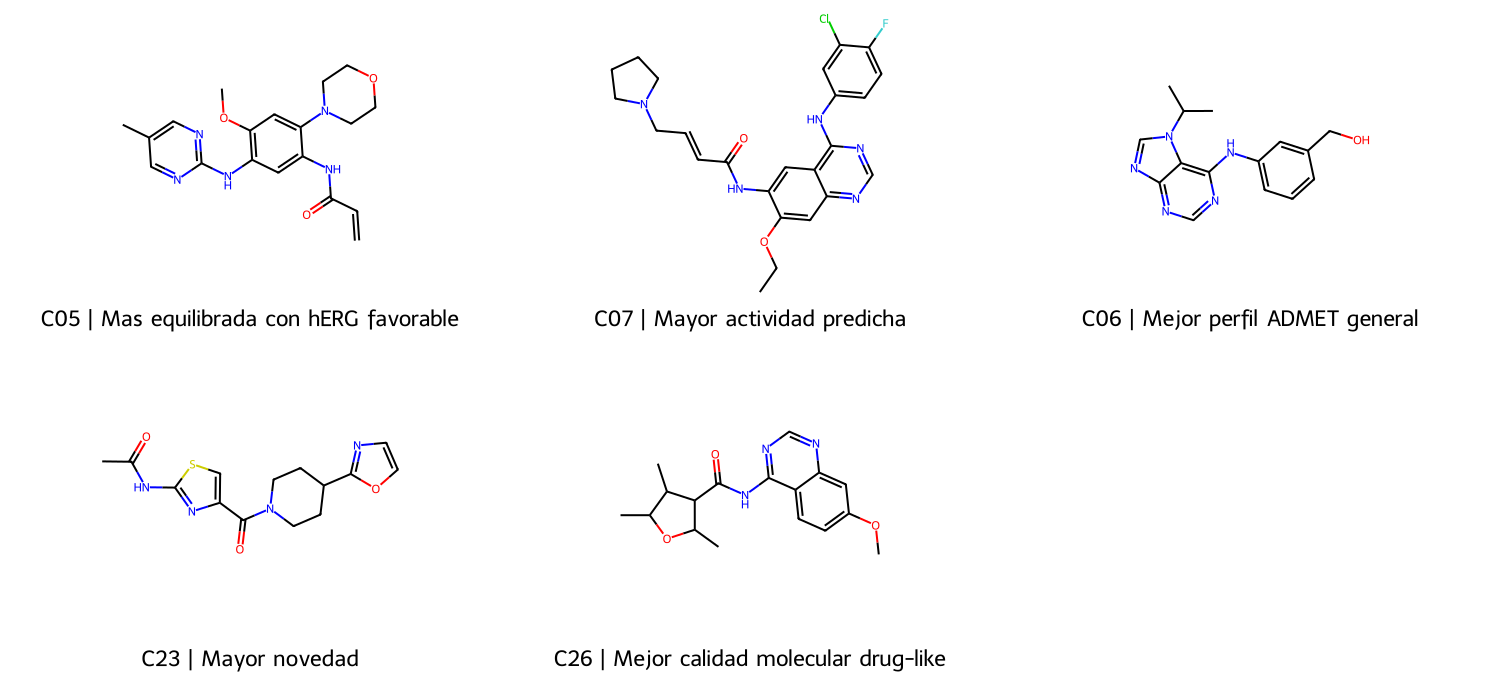

In [45]:
mols_profiles = []
legends_profiles = []

for _, row in df_profiles.iterrows():
    mol = Chem.MolFromSmiles(row["smiles"])
    if mol is None:
        raise ValueError(f"No se pudo convertir el SMILES de {row['candidate_id']}")

    rdDepictor.Compute2DCoords(mol)
    mols_profiles.append(mol)

    hERG_text = "hERG: sí" if row["pass_hERG"] else "hERG: no"
    legends_profiles.append(
        f"{row['candidate_id']} | {row['profile']}"
    )

draw_options = rdMolDraw2D.MolDrawOptions()
draw_options.legendFontSize = 22

img_profiles = Draw.MolsToGridImage(
    mols_profiles,
    molsPerRow=3,
    subImgSize=(500, 340),
    legends=legends_profiles,
    useSVG=False,
    returnPNG=False,
    drawOptions=draw_options,
)

save_rdkit_image(img_profiles, OUTPUT_DIR / "fig_perfiles_moleculares.png")
display(img_profiles)


## 16. Candidatas con posibles riesgos

Esta sección evita sobreprometer. Una molécula puede tener buen score y aun así requerir cautela por alertas ADMET, QED bajo, demasiadas violaciones de Lipinski o similitud excesiva con el conjunto de entrenamiento.


In [46]:
risk_flags = profile_base.copy()

risk_cols = [
    "candidate_id",
    "smiles",
    "predicted_pIC50",
    "reward_score",
    "n_risk_flags",
    "risk_admet_failure",
    "failed_admet_rules",
    "risk_hERG",
    "pass_hERG",
    "risk_near_training_copy",
    "max_tanimoto_training",
    "risk_low_qed",
    "qed",
    "risk_ro5",
    "ro5_violations",
]

display(
    risk_flags
    .sort_values(["n_risk_flags", "reward_score"], ascending=[False, False])[risk_cols]
    .head(15)
)

n_with_risks = int((risk_flags["n_risk_flags"] > 0).sum())
n_without_risks = int((risk_flags["n_risk_flags"] == 0).sum())
n_hERG_risk = int(risk_flags["risk_hERG"].sum())
n_general_admet_risk = int(risk_flags["risk_admet_failure"].sum())

print(f"Candidatas con al menos una señal de riesgo: {n_with_risks}")
print(f"Candidatas sin señales de riesgo: {n_without_risks}")
print(f"Candidatas que no superan hERG: {n_hERG_risk}")
print(f"Candidatas con fallos ADMET generales excluyendo hERG: {n_general_admet_risk}")

risk_flags[risk_cols].to_csv(OUTPUT_DIR / "tabla_riesgos_candidatas.csv", index=False)


,candidate_id,smiles,predicted_pIC50,reward_score,n_risk_flags,risk_admet_failure,failed_admet_rules,risk_hERG,pass_hERG,risk_near_training_copy,max_tanimoto_training,risk_low_qed,qed,risk_ro5,ro5_violations
6,C07,CCOc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CN1CCCC1,8.170641,0.701087,3,True,[pass_ClinTox],True,False,True,0.861111,False,0.443757,False,1
0,C01,COc1ccc2ncnc(Nc3cccc(Cl)c3F)c2c1,7.678820,0.813901,2,True,[pass_AMES],True,False,False,0.603774,False,0.788442,False,0
7,C08,COc1cc2ncnc(Nc3cc(F)ccc3F)c2cc1OC,6.930272,0.701011,2,True,[pass_AMES],True,False,False,0.733333,False,0.795479,False,0
15,C16,COc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OC1CN(C(=O)OC(C)(C)C)CC1F,7.569358,0.676497,2,False,[],True,False,False,0.592593,False,0.465007,True,2
19,C20,CC(=O)Nc1cc(Nc2ncnc3c2CCN(C)CC3)ccc1F,6.662008,0.663704,2,True,[pass_ClinTox],True,False,False,0.434211,False,0.904450,False,0
23,C24,Cc1cc(N2CCSCC2)ccc1NC(=O)/C=C/c1ccncn1,6.667808,0.644627,2,True,[pass_PAINS_alert],True,False,False,0.315789,False,0.867281,False,0
25,C26,COc1ccc2c(NC(=O)C3C(C)OC(C)C3C)ncnc2c1,6.502107,0.637404,2,True,[pass_AMES],True,False,False,0.472727,False,0.942319,False,0
26,C27,COc1cc2ncnc(NC(c3ccccc3)c3cnccn3)c2cc1NC(=O)c1cc2c(nc1O)CCC2=O,7.158876,0.634842,2,False,[],True,False,False,0.470588,True,0.278576,False,1
1,C02,O=C(Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1)C1CCOCC1,7.447770,0.792513,1,False,[],True,False,False,0.698413,False,0.641418,False,0
2,C03,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OC1CC2(COC2)C1,7.360564,0.776262,1,False,[],True,False,False,0.706897,False,0.649353,False,0


Candidatas con al menos una señal de riesgo: 21
Candidatas sin señales de riesgo: 9
Candidatas que no superan hERG: 18
Candidatas con fallos ADMET generales excluyendo hERG: 9


## 17. Conclusión operativa del notebook

El notebook 03 permitió pasar de un conjunto amplio de moléculas generadas a una shortlist de 30 candidatas mediante scoring, filtros ADMET, control de similitud y selección por Pareto. Este notebook 04 convierte esa shortlist en una lectura interpretable para la memoria.

La conclusión central es clara: **la shortlist no debe interpretarse como una lista de inhibidores validados**, sino como una cartera computacional de hipótesis priorizadas. Las candidatas más defendibles son las que equilibran actividad proxy, ADMET, QED, novedad razonable y diversidad estructural. Las moléculas con pIC50 muy alta pero alertas relevantes deben presentarse como hipótesis de mayor riesgo, no como “mejores candidatas” sin matices.

Para la tesis, esta lectura es más sólida que limitarse a ordenar por `predicted_pIC50`: demuestra que la pipeline funciona como sistema multiobjetivo de priorización temprana, no como una máquina de prometer fármacos.
